In [17]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Sonesh\Downloads\SUOMI_VIIRS_C2_Australia_NewZealand_48h.csv")
print(df.columns.tolist())

['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight']


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv(r"C:\Users\Sonesh\Downloads\SUOMI_VIIRS_C2_Australia_NewZealand_48h.csv")

# 2. Map the true date column (Change 'acq_date' if your printout showed something else)
date_column_name = 'acq_date' 

# 3. Safely convert and extract
df['Date'] = pd.to_datetime(df[date_column_name])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%b')

print("Success! Extracted time targets cleanly.")

Success! Extracted time targets cleanly.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the CORRECT historical dataset directly via URL
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df = pd.read_csv(URL)

# 2. Convert Date to datetime and extract Year/Month
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%b') 

print("Columns available now:", df.columns.tolist())

Columns available now: ['Region', 'Date', 'Estimated_fire_area', 'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power', 'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count', 'Replaced', 'Year', 'Month']


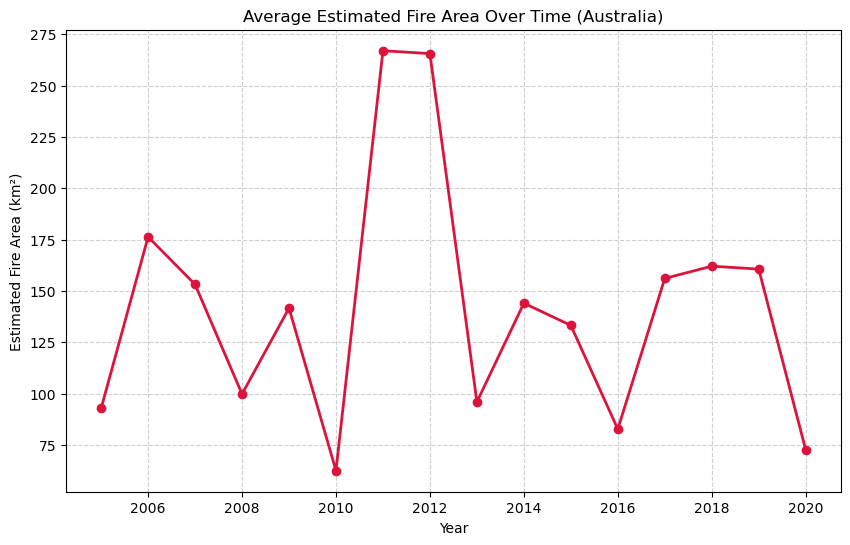

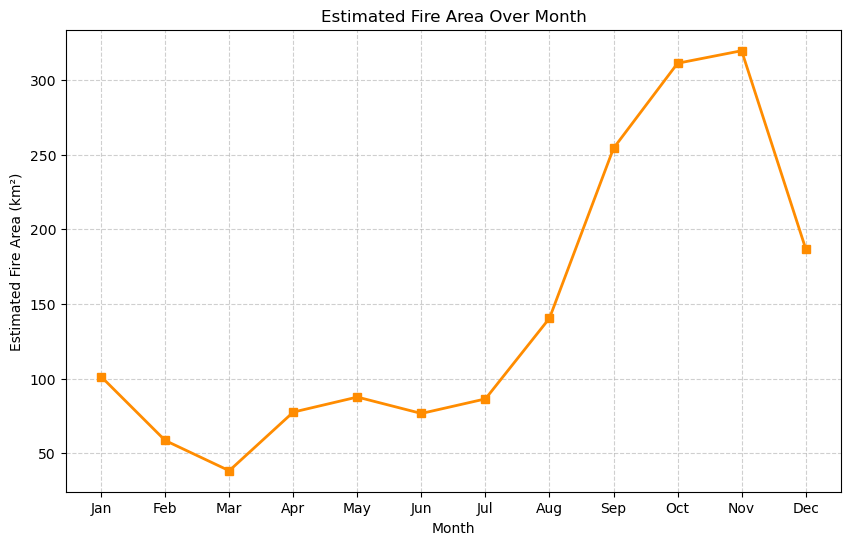

C:\Users\Sonesh\AppData\Local\Temp\ipykernel_15332\3157280755.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness', palette='YlOrRd')


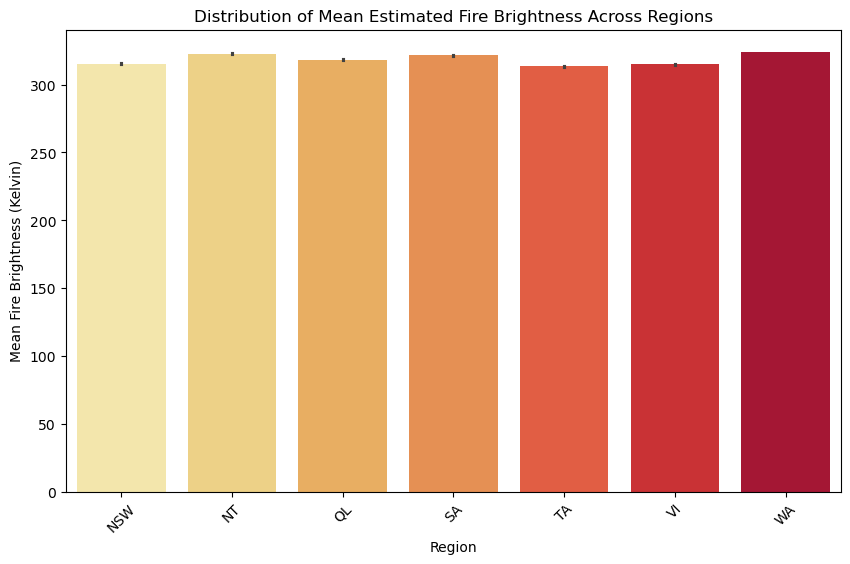

In [20]:
# TASK 1.1: Line Chart - Average Estimated Fire Area Over Time
plt.figure(figsize=(10, 6))
df_line = df.groupby('Year')['Estimated_fire_area'].mean().reset_index()
plt.plot(df_line['Year'], df_line['Estimated_fire_area'], marker='o', color='crimson', linewidth=2)
plt.title('Average Estimated Fire Area Over Time (Australia)')
plt.xlabel('Year')
plt.ylabel('Estimated Fire Area (km²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# TASK 1.2: Line Chart - Estimated Fire Area Over Month
plt.figure(figsize=(10, 6))
df_month = df.groupby('Month')['Estimated_fire_area'].mean().reindex(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
).reset_index()
plt.plot(df_month['Month'], df_month['Estimated_fire_area'], marker='s', color='darkorange', linewidth=2)
plt.title('Estimated Fire Area Over Month')
plt.xlabel('Month')
plt.ylabel('Estimated Fire Area (km²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# TASK 1.3: Seaborn Barplot - Mean Estimated Fire Brightness Across Regions
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Region', y='Mean_estimated_fire_brightness', palette='YlOrRd')
plt.title('Distribution of Mean Estimated Fire Brightness Across Regions')
plt.xlabel('Region')
plt.ylabel('Mean Fire Brightness (Kelvin)')
plt.xticks(rotation=45)
plt.show()

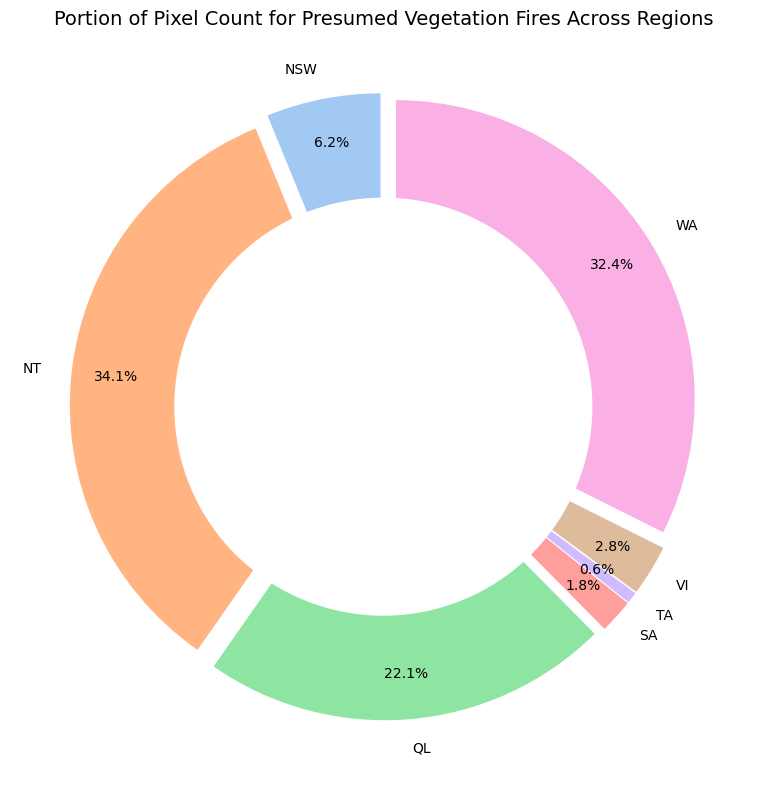

In [21]:
# TASK 1.4 & 1.5: Customized Pie Chart for Region Pixel Counts
df_pie = df.groupby('Region')['Count'].sum().reset_index()

plt.figure(figsize=(8, 8))
# Customizing with explode, percentages, and a clean color palette
explode_list = [0.05] * len(df_pie['Region']) 

plt.pie(
    df_pie['Count'], 
    labels=df_pie['Region'], 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.85, 
    explode=explode_list,
    colors=sns.color_palette('pastel')
)

# Turning it into a donut chart for a modern, customized look
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Portion of Pixel Count for Presumed Vegetation Fires Across Regions', fontsize=14)
plt.tight_layout()
plt.show()

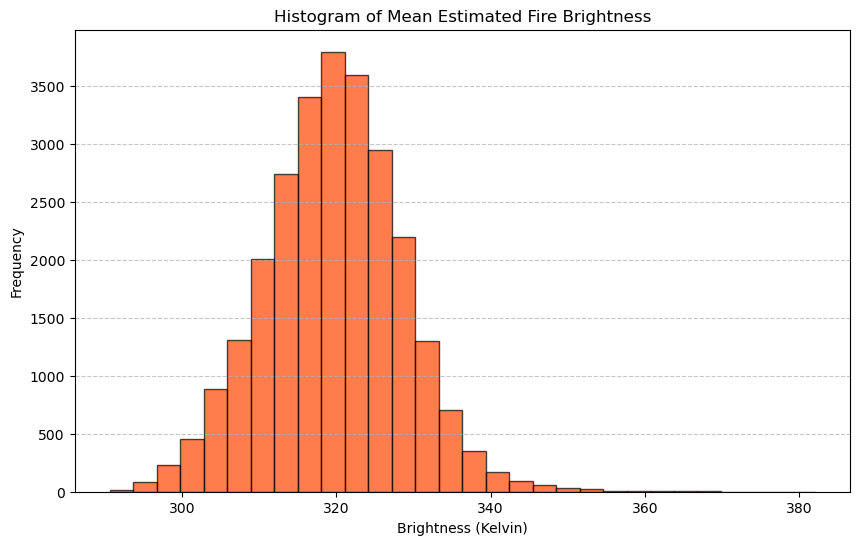

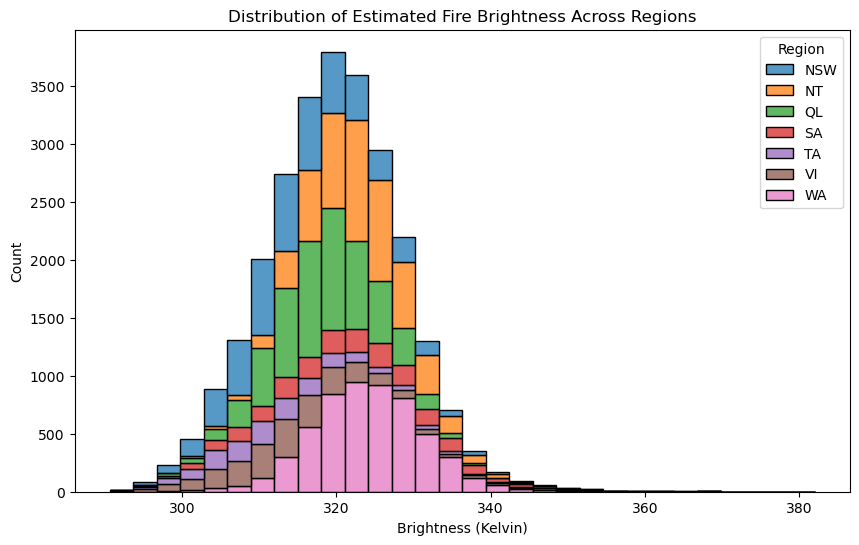

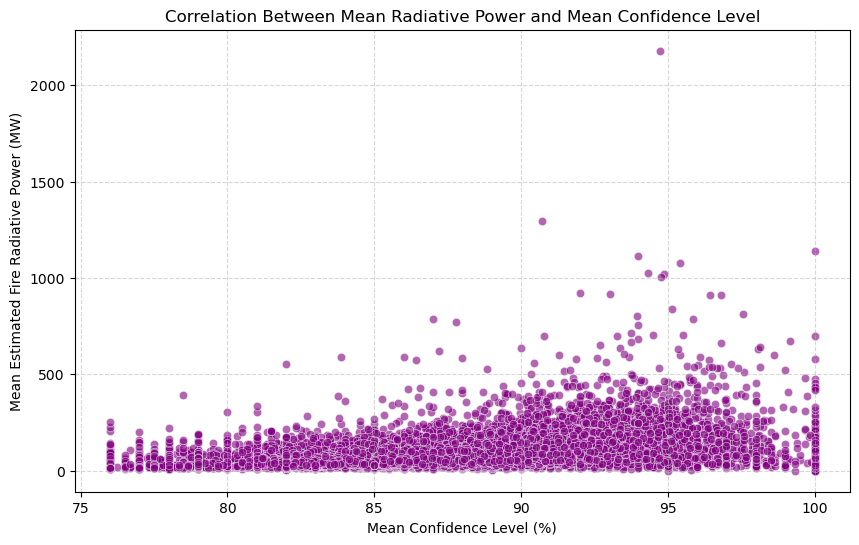

In [22]:
# TASK 1.6: Matplotlib Histogram of Mean Estimated Fire Brightness
plt.figure(figsize=(10, 6))
plt.hist(df['Mean_estimated_fire_brightness'], bins=30, color='orangered', edgecolor='black', alpha=0.7)
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.xlabel('Brightness (Kelvin)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# TASK 1.7: Seaborn Histogram with Hue by Region
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack', bins=30, palette='tab10')
plt.title('Distribution of Estimated Fire Brightness Across Regions')
plt.xlabel('Brightness (Kelvin)')
plt.ylabel('Count')
plt.show()

# TASK 1.8: Scatter Plot - Radiative Power vs. Confidence Level
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Mean_confidence', 
    y='Mean_estimated_fire_radiative_power', 
    alpha=0.6, 
    color='purple'
)
plt.title('Correlation Between Mean Radiative Power and Mean Confidence Level')
plt.xlabel('Mean Confidence Level (%)')
plt.ylabel('Mean Estimated Fire Radiative Power (MW)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [23]:
# TASK 1.9: Mark the 7 Regions on a Map of Australia
# Approximate coordinate centroids for the 7 Australian states/regions
region_coords = {
    'New South Wales': [-31.8402, 145.6128],
    'Victoria': [-37.4713, 144.7852],
    'Queensland': [-20.9176, 142.7028],
    'South Australia': [-30.0002, 135.2092],
    'Western Australia': [-27.6722, 121.6283],
    'Tasmania': [-42.0409, 146.8087],
    'Northern Territory': [-19.4914, 132.5510]
}

# Initialize map centered on Australia
aus_map = folium.Map(location=[-25.2744, 133.7751], zoom_start=4)

# Add markers for each region dynamically
for region, coords in region_coords.items():
    folium.Marker(
        location=coords,
        popup=f"Region: {region}",
        tooltip=f"Click for {region} Info",
        icon=folium.Icon(color='red', icon='fire', prefix='fa')
    ).add_to(aus_map)

# Save map to view in a browser
aus_map.save("australia_wildfires_map.html")
print("Map successfully saved as 'australia_wildfires_map.html'")

Map successfully saved as 'australia_wildfires_map.html'


In [24]:
import folium

# 1. Coordinate centroids matching the geographic layout of Australia
region_coords = {
    'New South Wales': [-31.8402, 145.6128],
    'Victoria': [-37.4713, 144.7852],
    'Queensland': [-20.9176, 142.7028],
    'South Australia': [-30.0002, 135.2092],
    'Western Australia': [-27.6722, 121.6283],
    'Tasmania': [-42.0409, 146.8087],
    'Northern Territory': [-19.4914, 132.5510]
}

# 2. Initialize map centered right in the middle of Australia
aus_map = folium.Map(location=[-25.2744, 133.7751], zoom_start=4)

# 3. Add markers dynamically using robust standard icons
for region, coords in region_coords.items():
    folium.Marker(
        location=coords,
        popup=f"Region: {region}",
        tooltip=f"Click for {region} Info",
        icon=folium.Icon(color='red', icon='info-sign') # Swapped to a standard built-in icon
    ).add_to(aus_map)

# 4. Save a physical copy to your computer
aus_map.save("australia_wildfires_map.html")
print("Map file saved successfully!")

# 5. CRITICAL STEP: Call the object alone at the end to render it inside the notebook window
aus_map

Map file saved successfully!


In [32]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

# 1. Initialize the app
app = dash.Dash(__name__)

# 2. Load the official assignment data directly from the cloud URL
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df = pd.read_csv(URL)

# Prep dates cleanly
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.strftime('%b')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 3. Define App Layout
app.layout = html.Div(children=[
    # TASK 2.1: Add title to the dashboard
    html.H1('Australia Wildfire Dashboard', 
            style={'textAlign': 'center', 'color': '#503D36', 'fontSize': '26px', 'padding': '10px'}),
    
    # TASK 2.2: Add the radio items and a dropdown selector inside an inner container
    html.Div([
        html.Div([
            html.Label('Select Region:', style={'fontWeight': 'bold'}),
            dcc.RadioItems(
                id='region-radio',
                options=[{'label': reg, 'value': reg} for reg in df['Region'].unique()],
                value=df['Region'].unique()[0], 
                inline=True,
                style={'padding': '5px'}
            )
        ], style={'width': '50%', 'display': 'inline-block'}),
        
        html.Div([
            html.Label('Select Year:', style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='year-dropdown',
                options=[{'label': str(yr), 'value': yr} for yr in sorted(df['Year'].unique())],
                value=sorted(df['Year'].unique())[0], 
                clearable=False,
                style={'padding': '5px'}
            )
        ], style={'width': '40%', 'display': 'inline-block'})
    ], style={'padding': '20px', 'backgroundColor': '#f9f9f9', 'borderRadius': '5px', 'marginBottom': '20px'}),
    
    # TASK 2.3: Add two empty divisions for output graphs side by side
    html.Div([
        html.Div(dcc.Graph(id='pie-chart'), style={'width': '50%', 'display': 'inline-block'}),
        html.Div(dcc.Graph(id='bar-chart'), style={'width': '50%', 'display': 'inline-block'})
    ])
])

# 4. Callbacks & Core Logic (TASK 2.4 & 2.5)
@app.callback(
    [Output(component_id='pie-chart', component_property='figure'),
     Output(component_id='bar-chart', component_property='figure')],
    [Input(component_id='region-radio', component_property='value'),
     Input(component_id='year-dropdown', component_property='value')]
)
def update_graphs(selected_region, selected_year):
    # Filter selection
    filtered_df = df[(df['Region'] == selected_region) & (df['Year'] == selected_year)]
    
    # Aggregate data by Month (using numeric_only=True to prevent Pandas warnings)
    monthly_data = filtered_df.groupby('Month').mean(numeric_only=True).reindex(month_order).reset_index()
    
    # Chart 1: Pie Chart on Monthly Average Estimated Fire Area
    pie_fig = px.pie(
        monthly_data, 
        values='Estimated_fire_area', 
        names='Month', 
        title=f'Monthly Average Estimated Fire Area in {selected_region} ({selected_year})',
        hole=0.3
    )
    
    # Chart 2: Bar Chart on Monthly Average Count of Pixels
    bar_fig = px.bar(
        monthly_data, 
        x='Month', 
        y='Count', 
        title=f'Monthly Average Count of Pixels for Presumed Vegetation Fires in {selected_region} ({selected_year})',
        labels={'Count': 'Average Pixel Count'}
    )
    bar_fig.update_layout(xaxis_title='Month', yaxis_title='Pixel Count')
    
    return pie_fig, bar_fig

# 5. Run the server 
if __name__ == '__main__':
    # use_reloader=False prevents notebook crashes
    app.run(debug=True, use_reloader=False)